In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import math
import random
import os  
import cv2
from PIL import Image
from torch import Tensor

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models, utils

%matplotlib inline
%load_ext autoreload
%autoreload 2

import torch.utils.data as Data
import matplotlib.pyplot as plt
import pandas as pd
import warnings#而这两句则是为了将程序运行时的警告显示去除用的
warnings.filterwarnings("ignore")
import torchvision
import sys

from collections import defaultdict
from tqdm import tqdm

def is_nan(nan):
    return not float('-inf') < nan < float('inf')
d_model = 4  # Embedding Size
max_len=1830

In [1]:
import torch

print("可用 GPU 数量:", torch.cuda.device_count())
print("当前卡号:", torch.cuda.current_device())
print("卡名:", torch.cuda.get_device_name(0))  # 0 换成你要看的卡号

# 查看当前用的设备
print("设备:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

可用 GPU 数量: 4
当前卡号: 0
卡名: NVIDIA GeForce RTX 4090
设备: cuda


/opt/anaconda3/envs/spectral_env/lib/python3.10/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5090 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5090 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [2]:
#加载数据
x_train = np.load('x_train.npy',allow_pickle=True).astype(float)
x_train = x_train.reshape(x_train.shape[0],1,x_train.shape[1])
print("load:x_train ",x_train.shape,is_nan(x_train.any()))
x_valid = np.load('x_val.npy',allow_pickle=True).astype(float)
x_valid = x_valid.reshape(x_valid.shape[0],1,x_valid.shape[1])
print("load:x_valid ",x_valid.shape,is_nan(x_valid.any()))
x_test = np.load('x_test.npy',allow_pickle=True).astype(float)
x_test = x_test.reshape(x_test.shape[0],1,x_test.shape[1])
print("load:x_test ",x_test.shape,is_nan(x_test.any()))
y_train = np.load('y_train.npy',allow_pickle=True)
#.astype(int)
print("load:y_train ",y_train.shape,is_nan(y_train.any()))
y_valid = np.load('y_val.npy',allow_pickle=True)
print("load:y_valid ",y_valid.shape,is_nan(y_valid.any()))
y_test = np.load('y_test.npy',allow_pickle=True)
print("load:y_test ",y_test.shape,is_nan(y_test.any()))
print(y_test)

load:x_train  (15360, 1, 7320) False
load:x_valid  (1920, 1, 7320) False
load:x_test  (1920, 1, 7320) False
load:y_train  (15360,) False
load:y_valid  (1920,) False
load:y_test  (1920,) False
[0. 0. 0. ... 1. 1. 1.]


In [3]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(1, 4),
            torch.nn.ReLU()
        )
        self.fc2 = nn.Sequential(
            nn.Linear(1, 4),
            torch.nn.ReLU()
        )
    def forward(self, x,r):
        enc_x=self.fc1(x)
        enc_r=self.fc2(r)
        enc=enc_x + enc_r
        return enc
#孪生网络
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.encoder = Encoder()
        self.fe1= nn.Sequential(
            torch.nn.Conv1d(in_channels=4,out_channels=4,kernel_size=10),
            torch.nn.BatchNorm1d(4),
            torch.nn.ReLU()
        )
        self.fe2= nn.Sequential(
            torch.nn.Conv1d(in_channels=4,out_channels=8,kernel_size=10),
            torch.nn.BatchNorm1d(8),
            torch.nn.ReLU()
        )
        self.maxpool=torch.nn.MaxPool1d((5))
        
        self.fc= nn.Sequential(
            nn.Flatten()
        )
        self.fc1= nn.Sequential(
#             torch.nn.BatchNorm1d(568),
            nn.Linear(568, 64),
            torch.nn.ReLU(),
        )
        self.fc2 = nn.Sequential(
#             torch.nn.BatchNorm1d(64),
            nn.Linear(64, 1),
            torch.nn.Sigmoid()
        )
        self.L1= nn.L1Loss(reduction='none')
        self.activation = nn.Sigmoid()
    def FeatureExtract(self, x,r):
        output= self.encoder(x,r).transpose(1,2)
        #B,C,L
#         print(output.shape)
        output= self.maxpool(self.fe1(output))
        output= self.maxpool(self.fe2(output))
        output=self.fc(output)
#         print(output.shape)
#         aaa
        output=self.fc1(output)
        return output
    def forward(self, x1,r1,x2,r2):
        output1 = self.FeatureExtract(x1,r1)
        output2 = self.FeatureExtract(x2,r2)
        euclidean_distance = self.activation(self.L1(output1, output2))
        euclidean_distance = self.fc2(euclidean_distance)
        return euclidean_distance


In [4]:
class MyDataset(Data.Dataset):
    def __init__(self, data, targets, transform=None):
        self.data = data
        self.targets = targets
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, index):
        x = self.data[index]
        y = self.targets[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
data_transform = transforms.Compose([
transforms.ToTensor()
])

batch_size=16
datasets = {
        "train": MyDataset(x_train,y_train,transform=data_transform),
        "valid": MyDataset(x_valid,y_valid,transform=data_transform),
        "test": MyDataset(x_test,y_test,transform=data_transform)
}
dataset_loader = {
    "train": torch.utils.data.DataLoader(datasets["train"], batch_size=batch_size, shuffle=True,pin_memory=False),
    "valid": torch.utils.data.DataLoader(datasets["valid"], batch_size=batch_size, shuffle=True,pin_memory=False),
    "test": torch.utils.data.DataLoader(datasets["test"], batch_size=batch_size, shuffle=True,pin_memory=False),
}

In [5]:
dataset_sizes = {
    i: len(datasets[i]) for i in datasets.keys()
}

print(dataset_sizes,datasets["train"][0])

for img, label in dataset_loader["train"]:
    print("tepoch的形状{}".format(img.shape))  
    print(label.shape,label)
    break

{'train': 15360, 'valid': 1920, 'test': 1920} (tensor([[[500.1387, 501.1029, 502.0672,  ...,   0.0000,   0.0000,   0.0000]]],
       dtype=torch.float64), 0.0)
tepoch的形状torch.Size([16, 1, 1, 7320])
torch.Size([16]) tensor([0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1.],
       dtype=torch.float64)


In [6]:
import torch.optim as optim
from collections import defaultdict
from tqdm import tqdm
max_len=1830
margin=2.0
#bce_loss = nn.BCELoss()
# 定义损失函数（使用自定义的Focal Loss）
#criterion = FocalLoss(gamma=2, weight=None)
def calc_loss(distance, label, metrics):
    batch = label.size(0)
    loss=F.binary_cross_entropy(distance.squeeze(), label.float())
    #print(loss)
    metrics['loss'] += loss.data.detach().cpu().numpy() * batch
    return loss

def print_metrics(metrics, epoch_samples, phase):    
    outputs = []
    for k in metrics.keys():
        outputs.append("{}: {:5f}".format(k, metrics[k] / epoch_samples))
    print("{}: {}".format(phase, ", ".join(outputs)))    

def train_model(model, optimizer, scheduler, device, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10
    best_epoch_num=0
    
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)
        since = time.time()

        # Each epoch has a training and validation phase
        for phase in ['train','valid']:
            right=0
            if phase == 'train':
                scheduler.step()
                for param_group in optimizer.param_groups:
                    print("LR", param_group['lr'])
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode
            metrics = defaultdict(float)
            epoch_samples = 0
            
            with tqdm(dataset_loader[phase], unit="batch") as tepoch:
                for inputs, labels in tepoch:
                    labels=labels.to(device)
                    #print(labels.shape,inputs.shape) 
                    r1=((inputs[:,:,:,0:max_len]-148)/3052).masked_fill(inputs[:,:,:,0:max_len]==0,0).reshape(inputs.shape[0],max_len,1).float().to(device)
                    x1=inputs[:,:,:,max_len*1:max_len*2].reshape(inputs.shape[0],max_len,1).float().to(device)
                    #print(x1.shape,r1.shape)
                    r2=((inputs[:,:,:,max_len*2:max_len*3]-148)/3052).masked_fill(inputs[:,:,:,max_len*2:max_len*3]==0,0).reshape(inputs.shape[0],max_len,1).float().to(device)
                    x2=inputs[:,:,:,max_len*3:max_len*4].reshape(inputs.shape[0],max_len,1).float().to(device)
                    #print(x2.shape,r2.shape)
                    #print(r2)
                    #print(r1.is_cuda,x1.is_cuda)
                    # zero the parameter gradients
                    optimizer.zero_grad()
                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(x1,r1,x2,r2)
                        #print(outputs,labels)
                        loss = calc_loss(outputs, labels, metrics)
                        #print(loss)
                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()
                        #print(outputs, labels)
                        label=labels.data.detach().cpu().numpy()
                        predict_label=torch.round(outputs).data.detach().cpu().numpy().reshape(inputs.size(0))
                        #print(label,predict_label)
                        right += np.sum(label==predict_label)
                        #print(right)
     # statistics
                    tepoch.set_postfix(loss=loss.item())
                    epoch_samples += inputs.size(0)

                print_metrics(metrics, epoch_samples, phase)
                epoch_loss = metrics['loss'] / epoch_samples
                print(metrics['loss']/ epoch_samples )
                epoch_right=right/epoch_samples
                
                # deep copy the model
                if phase == 'valid' and (epoch_loss < best_loss):
                    print("saving best model")
                    best_loss = epoch_loss
                    best_epoch_num=epoch
                    best_model_wts = copy.deepcopy(model.state_dict())
       
                history[phase].append(epoch_loss)
                print('Accuracy:{}%={}/{}'.format(epoch_right*100,right,epoch_samples))
            
        time_elapsed = time.time() - since
        print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
        model.load_state_dict(best_model_wts)   
        torch.save(model.state_dict(), "2trained_model_currentbestmodel.pt")
        
    # Save the model
    print('Best val loss: {:4f}'.format(best_loss))
    print('Epoch:{}'.format(best_epoch_num))    
    torch.save(model.state_dict(), "2trained_model_final_model.pt")
    np.save("history_train_loss.npy",np.array(history["train"]))
    np.save("history_valid_loss.npy",np.array(history["valid"]))
    return model

In [7]:
# from spectrum_encoder import SiameseNetwork
#实例化对象
model = SiameseNetwork()

#设备
device = 'cuda' if torch.cuda.is_available() else 'cpu'
cuda=1 if torch.cuda.is_available() else 0
model=model.to(device)#
device

# #把并行的模型移动到GPU上
# if torch.cuda.device_count() > 1:  # 检查电脑是否有多块GPU
#     print(f"Let's use {torch.cuda.device_count()} GPUs!")
#     model = nn.DataParallel(model)  # 将模型对象转变为多GPU并行运算的模型

# model.load_state_dict(torch.load('2trained_model_final_model.pt'))

'cuda'

In [8]:
from torch.optim import lr_scheduler
import time
import copy
import csv
# History
history = {"train": [], "valid": []}
# Observe that all parameters are being optimized
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=2e-5)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
model = train_model(model, optimizer, exp_lr_scheduler, device, num_epochs=100)

Epoch 0/99
----------
LR 0.01


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 960/960 [00:08<00:00, 110.92batch/s, loss=0.0255]


train: loss: 0.152995
0.15299457330159688
Accuracy:95.99609375%=14745/15360


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 330.60batch/s, loss=0.0305]


valid: loss: 0.053665
0.05366526550302903
saving best model
Accuracy:99.0625%=1902/1920
0m 9s
Epoch 1/99
----------
LR 0.01


...

valid: loss: 0.004526
0.004525571702833986
Accuracy:99.94791666666667%=1919/1920
0m 8s
Epoch 99/99
----------
LR 9.765625e-06


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 960/960 [00:07<00:00, 120.17batch/s, loss=0.000312]


train: loss: 0.001163
0.0011634433742983674
Accuracy:99.99348958333333%=15359/15360


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 336.61batch/s, loss=0.000514]


valid: loss: 0.004431
0.004430758268184339
Accuracy:99.94791666666667%=1919/1920
0m 8s
Best val loss: 0.004202
Epoch:89


In [9]:
model

SiameseNetwork(
  (encoder): Encoder(
    (fc1): Sequential(
      (0): Linear(in_features=1, out_features=4, bias=True)
      (1): ReLU()
    )
    (fc2): Sequential(
      (0): Linear(in_features=1, out_features=4, bias=True)
      (1): ReLU()
    )
  )
  (fe1): Sequential(
    (0): Conv1d(4, 4, kernel_size=(10,), stride=(1,))
    (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (fe2): Sequential(
    (0): Conv1d(4, 8, kernel_size=(10,), stride=(1,))
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (maxpool): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
  )
  (fc1): Sequential(
    (0): Linear(in_features=568, out_features=64, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
    (1): Sigmoid()
  )
  (L1): L1Loss()
  

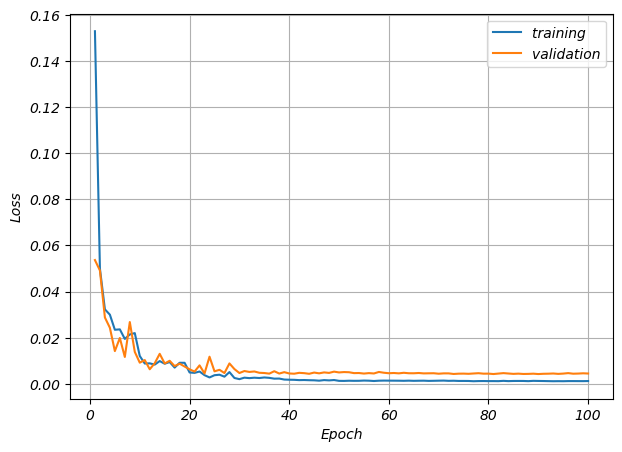

In [10]:
def plot_lc(plot_train, plot_val):

    # epochs
    n_epochs = len(plot_train)

    # X axis
    x = [i for i in range(1, n_epochs+1)]
    #x = [i+20 for i in range(80)]
    
    # plot loss
    fig = plt.figure(figsize=(7,5))
    fig.patch.set_facecolor('white')

    plt.xlabel('epoch')
    plt.plot(x, plot_train[:], label='training ')
    plt.plot(x, plot_val[:], label='validation')
    
#     plt.axvline(24,linestyle = '--',color = 'dimgrey')
    
    plt.legend()
#     plt.legend(loc='lower left', bbox_to_anchor= (0.0, 1.01), ncol=2, 
#             borderaxespad=0, frameon=False)
#     plt.tight_layout()
#     plt.title('Learning curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
#     plt.xlim((0,300))
    plt.grid(True)
#     plt.savefig('learning curve with stopping line.png')
    plt.show()
    
plot_lc(np.array(history["train"]), np.array(history["valid"]))

# Test-set

In [11]:
right=0
model.eval()   # Set model to evaluate mode
metrics = defaultdict(float)
epoch_samples = 0
history1 = {"test": []}
with tqdm(dataset_loader["test"], unit="batch") as tepoch:
    for inputs, labels in tepoch:
        labels=labels.to(device)
        r1=((inputs[:,:,:,0:max_len]-148)/3052).masked_fill(inputs[:,:,:,0:max_len]==0,0).reshape(inputs.shape[0],max_len,1).float().to(device)
        x1=inputs[:,:,:,max_len*1:max_len*2].reshape(inputs.shape[0],max_len,1).float().to(device)
        r2=((inputs[:,:,:,max_len*2:max_len*3]-148)/3052).masked_fill(inputs[:,:,:,max_len*2:max_len*3]==0,0).reshape(inputs.shape[0],max_len,1).float().to(device)
        x2=inputs[:,:,:,max_len*3:max_len*4].reshape(inputs.shape[0],max_len,1).float().to(device)
        outputs = model(x1,r1,x2,r2)
        label=labels.data.detach().cpu().numpy()
        predict_label=torch.round(outputs).data.detach().cpu().numpy().reshape(inputs.size(0))
        print(outputs>0.5*1)
        right += np.sum(label==predict_label)
        epoch_samples += inputs.size(0)
#     print_metrics(metrics, epoch_samples, phase)
    epoch_loss = metrics['loss'] / epoch_samples
    epoch_right=right/epoch_samples
    history1["test"].append(epoch_loss)
    print('Accuracy:{}%={}/{}'.format(epoch_right*100,right,epoch_samples))


  0%|                                                                                                                                      | 0/120 [00:00<?, ?batch/s]

tensor([[ True],
        [False],
        [ True],
        [ True],
        [False],
        [ True],
        [ True],
        [False],
        [ True],
        [False],
        [False],
        [False],
        [ True],
        [False],
        [ True],
        [False]], device='cuda:0')
tensor([[ True],
        [ True],
        [ True],
        [ True],
        [False],
        [False],
        [ True],
        [False],
        [ True],
        [False],
        [ True],
        [ True],
        [False],
        [False],
        [ True],
        [False]], device='cuda:0')
tensor([[False],
        [ True],
        [False],
        [False],
        [False],
        [ True],
        [False],
        [ True],
        [False],
        [ True],
        [ True],
        [ True],
        [ True],
        [False],
        [False],
        [False]], device='cuda:0')
tensor([[False],
        [False],
        [ True],
        [ True],
        [False],
        [False],
        [ True],
        [Fa

 87%|██████████████████████████████████████████████████████████████████████████████████████████████████████████▌                | 104/120 [00:00<00:00, 518.62batch/s]

tensor([[ True],
        [ True],
        [False],
        [False],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [False],
        [False],
        [False],
        [False],
        [False]], device='cuda:0')
tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [ True],
        [ True],
        [False],
        [False],
        [False],
        [False],
        [ True],
        [False],
        [False]], device='cuda:0')
tensor([[False],
        [False],
        [ True],
        [ True],
        [ True],
        [ True],
        [False],
        [False],
        [ True],
        [ True],
        [False],
        [ True],
        [False],
        [False],
        [ True],
        [False]], device='cuda:0')
tensor([[False],
        [False],
        [ True],
        [ True],
        [False],
        [ True],
        [ True],
        [Fa

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 514.36batch/s]

tensor([[ True],
        [ True],
        [ True],
        [ True],
        [False],
        [False],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [False],
        [ True],
        [False],
        [False]], device='cuda:0')
tensor([[False],
        [ True],
        [False],
        [False],
        [ True],
        [ True],
        [False],
        [ True],
        [False],
        [ True],
        [ True],
        [ True],
        [ True],
        [False],
        [ True],
        [ True]], device='cuda:0')
tensor([[False],
        [False],
        [False],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [False],
        [False],
        [ True],
        [False],
        [ True],
        [ True],
        [False]], device='cuda:0')
tensor([[ True],
        [ True],
        [False],
        [False],
        [False],
        [ True],
        [ True],
        [Fa